In [1]:
import yfinance as yf
import datetime
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from icecream import ic


# Define the tickers
tickers = ["^GSPC", "^IXIC", "^DJI"]  # S&P 500, NASDAQ, Dow Jones

index_names = {"^GSPC": "S&P 500",
              "^IXIC": "NASDAQ", # "NASDAQ Composite",
              "^DJI": "Dow Jones"} # "Dow Jones Industrial Average"}

# Define the start and end date
start_date = "2025-01-20"
#end_date = "2025-04-04"  # What I used for my HandsOff! day poster
end_date = datetime.date.today()

# Download the data
data = yf.download(tickers, start=start_date, end=end_date)

# Print the head of the data
print(data.head())

# Print the tail of the data
print(data.tail())


YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  3 of 3 completed

Price              Close                                     High  \
Ticker              ^DJI        ^GSPC         ^IXIC          ^DJI   
Date                                                                
2025-01-21  44025.808594  6049.240234  19756.779297  44050.128906   
2025-01-22  44156.730469  6086.370117  20009.339844  44208.339844   
2025-01-23  44565.070312  6118.709961  20053.679688  44565.261719   
2025-01-24  44424.250000  6101.240234  19954.300781  44545.519531   
2025-01-27  44713.578125  6012.279785  19341.830078  44727.851562   

Price                                           Low               \
Ticker            ^GSPC         ^IXIC          ^DJI        ^GSPC   
Date                                                               
2025-01-21  6051.509766  19789.630859  43528.648438  6006.879883   
2025-01-22  6100.810059  20068.519531  44042.109375  6076.129883   
2025-01-23  6118.729980  20053.679688  44113.550781  6074.669922   
2025-01-24  6128.180176  20118.609375  

In [2]:
data.head()

Price              Close                                     High  \
Ticker              ^DJI        ^GSPC         ^IXIC          ^DJI   
Date                                                                
2025-01-21  44025.808594  6049.240234  19756.779297  44050.128906   
2025-01-22  44156.730469  6086.370117  20009.339844  44208.339844   
2025-01-23  44565.070312  6118.709961  20053.679688  44565.261719   
2025-01-24  44424.250000  6101.240234  19954.300781  44545.519531   
2025-01-27  44713.578125  6012.279785  19341.830078  44727.851562   

Price                                           Low               \
Ticker            ^GSPC         ^IXIC          ^DJI        ^GSPC   
Date                                                               
2025-01-21  6051.509766  19789.630859  43528.648438  6006.879883   
2025-01-22  6100.810059  20068.519531  44042.109375  6076.129883   
2025-01-23  6118.729980  20053.679688  44113.550781  6074.669922   
2025-01-24  6128.180176  20118.609375  44332.218750  6088.740234   
2025-01-27  6017.169922  19514.349609  44026.269531  5962.919922   

Price                             Open                                 Volume  \
Ticker             ^IXIC          ^DJI        ^GSPC         ^IXIC        ^DJI   
Date                                                                            
2025-01-21  19551.169922  43528.648438  6014.120117  19734.390625   592210000   
2025-01-22  19903.050781  44178.058594  6081.390137  19903.050781   588430000   
2025-01-23  19892.550781  44113.550781  6076.319824  19906.990234   444180000   
2025-01-24  19897.130859  44533.750000  6121.430176  20087.109375   532230000   
2025-01-27  19204.949219  44148.839844  5969.040039  19234.039062  1230150000   

Price                               
Ticker           ^GSPC       ^IXIC  
Date                                
2025-01-21  4702920000  8015780000  
2025-01-22  4323040000  7219060000  
2025-01-23  4432250000  6837700000  
2025-01-24  4214250000  7708150000  
2025-01-27  5198750000  8870200000

In [3]:
df_tall = data.stack(level=list(range(data.columns.nlevels)))
df_tall.reset_index()

C:\Users\scott\AppData\Local\Temp\ipykernel_13824\1505085652.py:1: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  df_tall = data.stack(level=list(range(data.columns.nlevels)))


,Date,Price,Ticker,0
0,2025-01-21,Close,^DJI,4.402581e+04
1,2025-01-21,Close,^GSPC,6.049240e+03
2,2025-01-21,Close,^IXIC,1.975678e+04
3,2025-01-21,High,^DJI,4.405013e+04
4,2025-01-21,High,^GSPC,6.051510e+03
...,...,...,...,...
925,2025-04-17,Open,^GSPC,5.305450e+03
926,2025-04-17,Open,^IXIC,1.639997e+04
927,2025-04-17,Volume,^DJI,6.574000e+08
928,2025-04-17,Volume,^GSPC,4.714880e+09


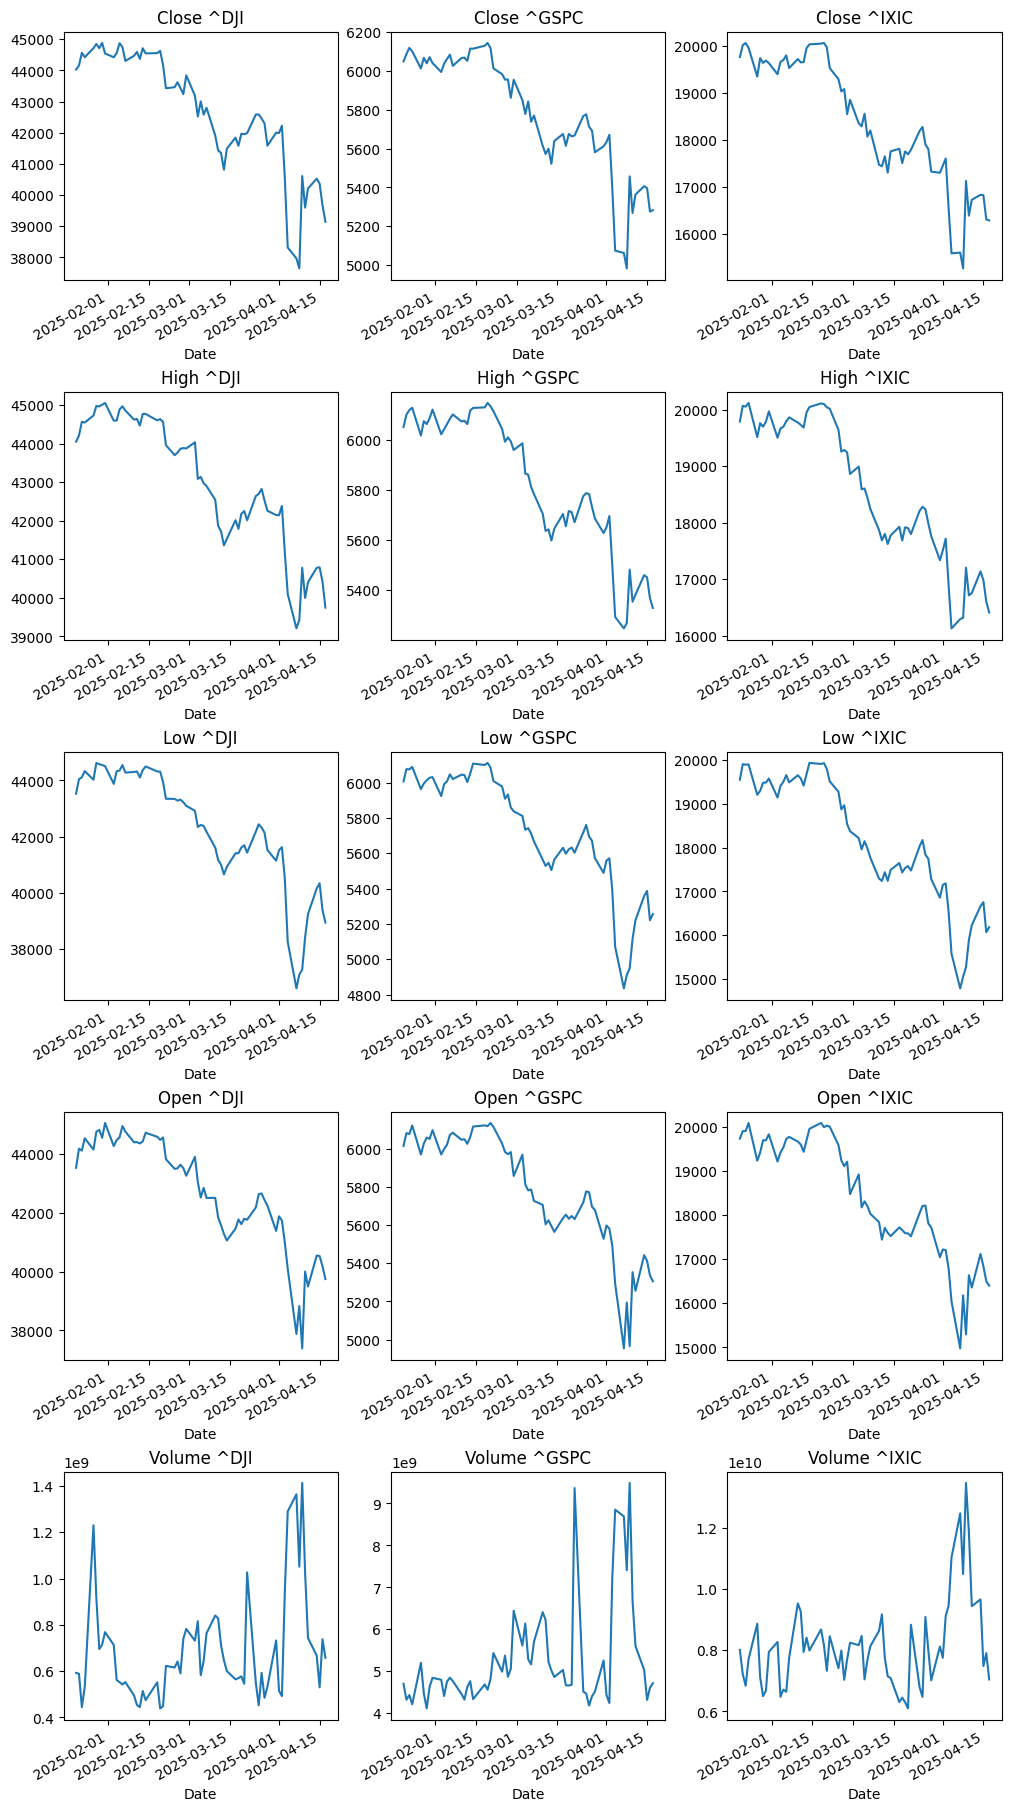

In [4]:
from matplotlib.pyplot import pcolor
from pydantic import constr


# def multi_index_to_columns(df):
#     df.columns = df.columns.to_flat_index()
#     df.columns = [str(i) + '_' + str(j) for i, j in df.columns]
#     return df

sindex_subplot_index = pd.Series(np.unique(np.array(data.columns.to_list())[:,1]))
sindex_subplot_index = pd.Series(sindex_subplot_index.index, sindex_subplot_index.values)

param_subplot_index = pd.Series(np.unique(np.array(data.columns.to_list())[:,0]))
param_subplot_index = pd.Series(param_subplot_index.index, param_subplot_index.values)

# pltIx = pd.Series()
# indices = pd.Series(np.unique(np.array(data.columns.to_list())[:,1]))
fig, axes = plt.subplots(len(param_subplot_index), len(sindex_subplot_index), figsize=(10, 18),
                         layout='constrained')

for param, sindex in data.columns.to_list():
    #ic(param, sindex, param_subplot_index[param], sindex_subplot_index[sindex])
    ax = axes[param_subplot_index[param], sindex_subplot_index[sindex]]
    data[(param, sindex)].plot(ax=ax, title=param + ' ' + sindex)
    ax.set_xlabel('Date')

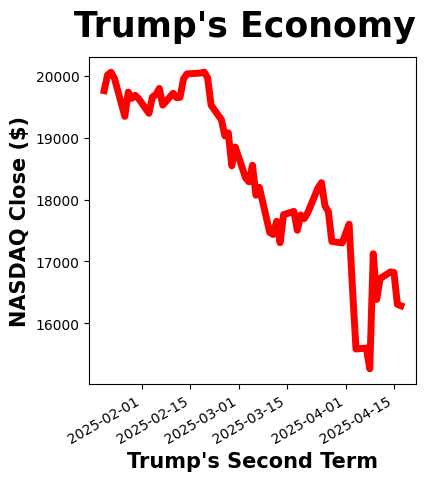

In [5]:
#param, index = 'Open', '^IXIC'
param, index = 'Close', '^IXIC' # big del pct
#param, index = 'Close', '^GSPC' # not monotonic enough
index_name = index_names[index]

ax = plt.subplot()
plt.rcParams['axes.linewidth'] = 4  # plot box
plt.rcParams['xtick.major.size'] = 8    # Length of major ticks in points
plt.rcParams['xtick.major.width'] = 2   # Width of major ticks in points
plt.rcParams['ytick.major.size'] = 8    # Length of major ticks in points
plt.rcParams['ytick.major.width'] = 2   # Width of major ticks in points

data[(param, index)].plot(ax=ax,c='r', linewidth=5)
ax.set_box_aspect(1)

#plt.xlabel('Date', fontweight='bold', fontsize=15)  # Increased size and bold
#plt.xlabel('', fontweight='bold', fontsize=15)  # Increased size and bold
plt.xlabel("Trump's Second Term", fontweight='bold', fontsize=15)  # Increased size and bold
plt.ylabel(f'{index_name} {param} ($)', fontweight='bold', fontsize=15)  # Increased size and bold
#plt.title(f"Trump's Economy", fontweight='bold', fontsize=25) # Increased size and bold
plt.rc('xtick', labelsize=14) # set the label size
plt.rc('ytick', labelsize=14) # set the label sizet
plt.suptitle(f"Trump's Economy", fontweight='bold', fontsize=25); # Increased size and bold

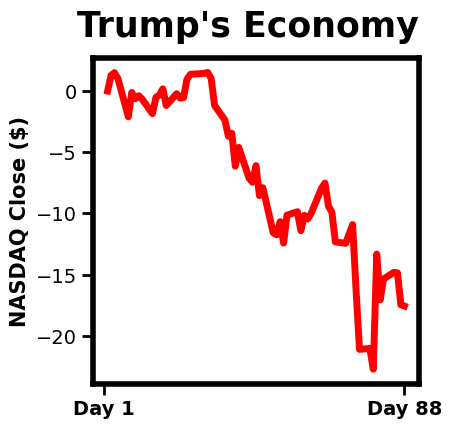

In [6]:
ax = plt.subplot()
plt.rcParams['axes.linewidth'] = 2  # plot box
plt.rcParams['xtick.major.size'] = 8    # Length of major ticks in points
plt.rcParams['xtick.major.width'] = 2   # Width of major ticks in points
plt.rcParams['ytick.major.size'] = 8    # Length of major ticks in points
plt.rcParams['ytick.major.width'] = 2   # Width of major ticks in points

pltDat = data[(param, index)].copy()
doPct = True
if doPct:
    day1_index =pltDat.iloc[0]
    pltDat = (pltDat - day1_index) / day1_index * 100
    
pltDat.plot(ax=ax,c='r', linewidth=5)    
#data[(param, index)].plot(ax=ax,c='r', linewidth=5)
ax.set_box_aspect(1)

# Define the inauguration date
inauguration_date = datetime.datetime(2025, 1, 20)

# Define today's date
today_date = data.index[-1].to_pydatetime() #datetime(2025, 1, 24)

# Calculate the day number for today
n = (today_date - inauguration_date).days + 1

# Set x-axis ticks and labels
ax.set_xticks([inauguration_date, today_date])
ax.set_xticklabels(['Day 1', f'Day {n}'])

# Ensure labels are not rotated and are horizontally centered
for label in ax.get_xticklabels():
    label.set_rotation(0)
    label.set_horizontalalignment('center')
    label.set_fontweight('bold')  # Make tick labels bold

plt.xlabel("")  # Hide the x label
#plt.xlabel("Trump's Second Term", fontweight='bold', fontsize=15)  # Increased size and bold
plt.ylabel(f'{index_name} {param} ($)', fontweight='bold', fontsize=15)  # Increased size and bold
plt.rc('xtick', labelsize=14) # set the label size
plt.rc('ytick', labelsize=14) # set the label size
plt.suptitle(f"Trump's Economy", fontweight='bold', fontsize=25); # Increased size and bold

plt.show()


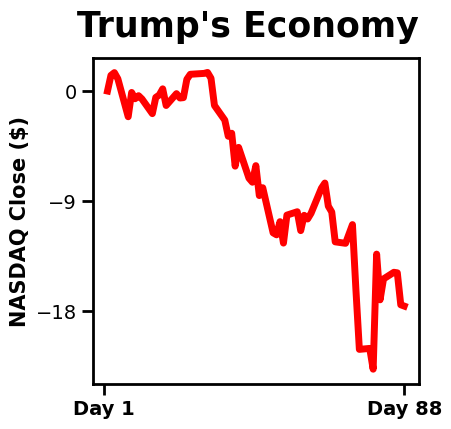

In [7]:
ax = plt.subplot()
plt.rcParams['axes.linewidth'] = 2  # plot box
plt.rcParams['xtick.major.size'] = 8    # Length of major ticks in points
plt.rcParams['xtick.major.width'] = 2   # Width of major ticks in points
plt.rcParams['ytick.major.size'] = 8    # Length of major ticks in points
plt.rcParams['ytick.major.width'] = 2   # Width of major ticks in points

pltDat = data[(param, index)].copy()
doPct = True
if doPct:
    day1_index =pltDat.iloc[0]
    pltDat = (pltDat - day1_index) / day1_index * 100
    
pltDat.plot(ax=ax,c='r', linewidth=5)    
#data[(param, index)].plot(ax=ax,c='r', linewidth=5)
ax.set_box_aspect(1)

# Define the inauguration date
inauguration_date = datetime.datetime(2025, 1, 20)

# Define today's date
today_date = data.index[-1].to_pydatetime() #datetime(2025, 1, 24)

# Calculate the day number for today
n = (today_date - inauguration_date).days + 1

# Set x-axis ticks and labels
ax.set_xticks([inauguration_date, today_date])
ax.set_xticklabels(['Day 1', f'Day {n}'])

# Ensure labels are not rotated and are horizontally centered
for label in ax.get_xticklabels():
    label.set_rotation(0)
    label.set_horizontalalignment('center')
    label.set_fontweight('bold')  # Make tick labels bold

plt.xlabel("")  # Hide the x label
#plt.xlabel("Trump's Second Term", fontweight='bold', fontsize=15)  # Increased size and bold
plt.ylabel(f'{index_name} {param} ($)', fontweight='bold', fontsize=15)  # Increased size and bold
plt.rc('xtick', labelsize=14) # set the label size
plt.rc('ytick', labelsize=14) # set the label size

# Calculate the y-axis tick values
value_at_start = pltDat.iloc[0]
value_at_end = round(pltDat.iloc[-1])
middle_index = len(pltDat) // 2
value_at_middle = round(pltDat.iloc[middle_index])

# Set the y-axis ticks
ax.set_yticks([value_at_start, value_at_middle, value_at_end])

plt.suptitle(f"Trump's Economy", fontweight='bold', fontsize=25); # Increased size and bold

plt.show()


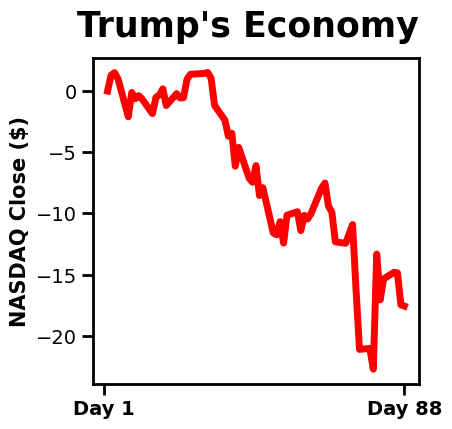

In [8]:
doPct = True
plot_mid_value = False  # added option

ax = plt.subplot()
plt.rcParams['axes.linewidth'] = 2  # plot box
plt.rcParams['xtick.major.size'] = 8    # Length of major ticks in points
plt.rcParams['xtick.major.width'] = 2   # Width of major ticks in points
plt.rcParams['ytick.major.size'] = 8    # Length of major ticks in points
plt.rcParams['ytick.major.width'] = 2   # Width of major ticks in points

pltDat = data[(param, index)].copy()
if doPct:
    day1_index = pltDat.iloc[0]
    pltDat = (pltDat - day1_index) / day1_index * 100

pltDat.plot(ax=ax, c='r', linewidth=5)
ax.set_box_aspect(1)

# Define the inauguration date
inauguration_date = datetime.datetime(2025, 1, 20)

# Define today's date
today_date = data.index[-1].to_pydatetime()

# Calculate the day number for today
n = (today_date - inauguration_date).days + 1

# Set x-axis ticks and labels
ax.set_xticks([inauguration_date, today_date])
ax.set_xticklabels(['Day 1', f'Day {n}'])

# Ensure labels are not rotated and are horizontally centered
for label in ax.get_xticklabels():
    label.set_rotation(0)
    label.set_horizontalalignment('center')
    label.set_fontweight('bold')  # Make tick labels bold

plt.xlabel("")  # Hide the x label
plt.ylabel(f'{index_name} {param} ($)', fontweight='bold', fontsize=15)  # Increased size and bold
plt.rc('xtick', labelsize=14) # set the label size
plt.rc('ytick', labelsize=14) # set the label size
plt.suptitle(f"Trump's Economy", fontweight='bold', fontsize=25); # Increased size and bold

if plot_mid_value:
    # Calculate the middle index
    m = len(pltDat) // 2

    # Get the y-axis values at the start, middle, and end
    y_start = pltDat.iloc[0]
    y_middle = pltDat.iloc[m]
    y_end = pltDat.iloc[-1]

    # Round the middle and end values
    y_start_rounded = round(y_start, 1)
    y_middle_rounded = round(y_middle, 1)
    y_end_rounded = round(y_end, 1)

    # Set the y-axis ticks
    ax.set_yticks([y_start_rounded, y_middle_rounded, y_end_rounded])
    
    # Set the y-axis tick labels to show percentages
    ax.set_yticklabels([f'{y_start_rounded} %', f'{y_middle_rounded} %', f'{y_end_rounded} %'])

    # Calculate the day number for the middle tick
    middle_date = pltDat.index[m].to_pydatetime()
    middle_day_number = (middle_date - inauguration_date).days + 1

    # Add an x-axis tick for the middle date
    ax.set_xticks([inauguration_date, pltDat.index[m].to_pydatetime(), today_date])
    ax.set_xticklabels(['Day 1', f'Day {middle_day_number}', f'Day {n}'])

    # Ensure labels are not rotated and are horizontally centered
    for label in ax.get_xticklabels():
        label.set_rotation(0)
        label.set_horizontalalignment('center')
        label.set_fontweight('bold')  # Make tick labels bold

plt.show()


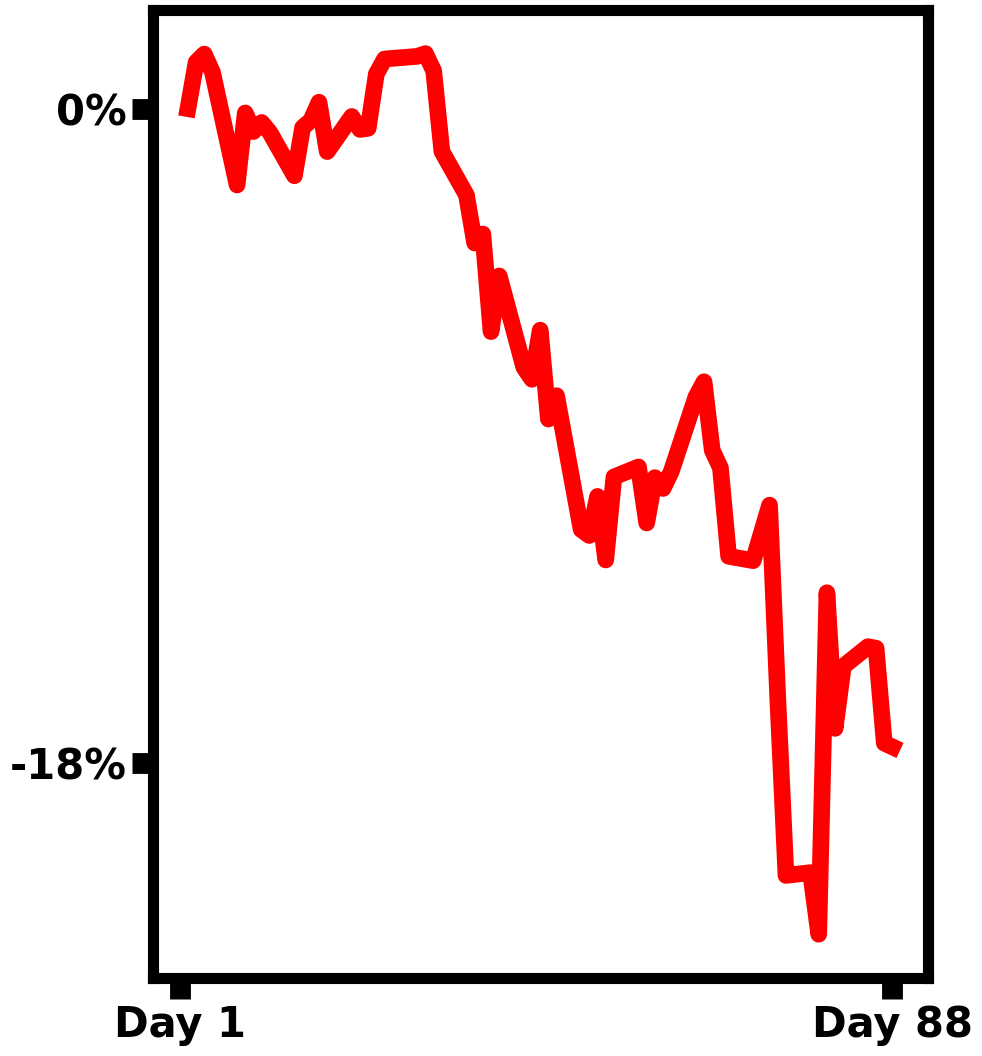

In [9]:
from ast import If
from ssl import ALERT_DESCRIPTION_DECRYPT_ERROR


doPct = True
plot_label_type = 'end_only'  # 'standard', 'end_only', 'end_mid'
econ_title = False
linewidth = 12 # plot line width
aspect_ratio = 1.25 # aspect ratio of the plot
label_spec_axis = {'fontsize': 30, 'fontweight': 'bold'}  # label size and weight
boxlinewidth = 8 # width of the plot box lines
#ytick_label_rotation = 270 # rotation of y-axis tick labels
    
fig, ax = plt.subplots(1,1, figsize=(10, 18))
for spine in ax.spines.values():
    spine.set_linewidth(boxlinewidth)  # Set the width of the plot box lines

ax.tick_params(axis='both', which='major', width=15, length=15)  # Major ticks
ax.tick_params(axis='both', which='minor', width=10, length=10)   # Minor ticks

pltDat = data[(param, index)].copy()
if doPct:
    day1_index = pltDat.iloc[0]
    pltDat = (pltDat - day1_index) / day1_index * 100

pltDat.plot(ax=ax, c='r', linewidth=linewidth)
ax.set_box_aspect(aspect_ratio)

# Define the inauguration date
inauguration_date = datetime.datetime(2025, 1, 20)

# Define today's date
today_date = data.index[-1].to_pydatetime()

# Calculate the day number for today
n = (today_date - inauguration_date).days + 1

# Calculate the middle index
m = len(pltDat) // 2

# Get the y-axis values at the start, middle, and end
y_start = pltDat.iloc[0]
y_middle = pltDat.iloc[m]
y_end = pltDat.iloc[-1]

# Round the start, middle, and end values
y_start_rounded = round(y_start)
y_middle_rounded = round(y_middle)
y_end_rounded = round(y_end)
sig_digs = 1
# y_start_rounded = round(y_start, sig_digs)
# y_middle_rounded = round(y_middle, sig_digs)
# y_end_rounded = round(y_end, sig_digs)

# Calculate the day number for the middle tick
middle_date = pltDat.index[m].to_pydatetime()
middle_day_number = (middle_date - inauguration_date).days + 1

if plot_label_type == 'standard':
    # Set the y-axis ticks
    ax.set_yticks([y_start_rounded, y_middle_rounded, y_end_rounded])

    # Set the y-axis tick labels to show percentages
    ax.set_yticklabels([f'{y_start_rounded} %', f'{y_middle_rounded} %', f'{y_end_rounded} %'], 
                       **label_spec_axis)

    # Set x-axis ticks and labels
    ax.set_xticks([inauguration_date, middle_date, today_date])
    ax.set_xticklabels(['Day 1', f'Day {middle_day_number}', f'Day {n}'],
                       **label_spec_axis)

elif plot_label_type == 'end_only':
    # Set the y-axis ticks
    ax.set_yticks([y_start_rounded, y_end_rounded])

    # Set the y-axis tick labels to show percentages
    ax.set_yticklabels([f'{y_start_rounded:d}%', f'{y_end_rounded:d}%'],
                       **label_spec_axis)
    # ax.set_yticklabels([f'{y_start_rounded} %', f'{y_end_rounded} %'],
    #                    **label_spec_axis)

    # Set x-axis ticks and labels
    ax.set_xticks([inauguration_date, today_date])
    ax.set_xticklabels(['Day 1', f'Day {n}'],
                       **label_spec_axis)
                       

elif plot_label_type == 'end_mid':
    # Set the y-axis ticks
    ax.set_yticks([y_start_rounded, y_middle_rounded, y_end_rounded])

    # Set the y-axis tick labels to show percentages
    ax.set_yticklabels([f'{y_start_rounded} %', f'{y_middle_rounded} %', f'{y_end_rounded} %'],
                       **label_spec_axis)

    # Set x-axis ticks and labels
    ax.set_xticks([inauguration_date, middle_date, today_date])
    ax.set_xticklabels(['Day 1', f'Day {middle_day_number}', f'Day {n}'],
                       **label_spec_axis)

else:  # Default to standard if the value is not recognized
    raise Exception(f'unknown plot_label_type: {plot_label_type}')

# Common formatting for x-axis labels
ax.set_xticklabels(ax.get_xticklabels(), rotation=0, ha='center',
                   **label_spec_axis)  # Make tick labels bold

# for label in ax.get_yticklabels():
#     label.set_rotation(ytick_label_rotation)
#     #label.set_horizontalalignment('center')
#     label.set_verticalalignment('center') 

plt.xlabel("")  # Hide the x label

if doPct:
    ylabel_unit = '(% change)'
else:
    ylabel_unit  = '($)'

plot_info = f'{index_name} {param}'
if econ_title:
    plt.suptitle(f"Trump's Economy", fontweight='bold', fontsize=25);
    ylabel = f'{plot_info} {ylabel_unit}'        
    plt.ylabel(ylabel, **label_spec_axis)  # Increased size and bold
else:
    #plt.title(plot_info, fontweight='bold')
    #plt.ylabel(ylabel_unit, **labelspec)
    plt.ylabel("", **label_spec_axis)